In [1]:
import numpy, pandas, sklearn, matplotlib
print("all good")


all good


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Task Python Fundamentals
### 2.1 Data Types
I  will create variables related to disease information.

In [3]:
disease_name = "Malaria"
number_of_cases = 150
recovery_rate = 0.87
treatment_available = True

print("Disease:", disease_name)
print("Number of cases:", number_of_cases)
print("Recovery rate:", recovery_rate)
print("Treatment available:", treatment_available)

print("\nData types:")
print(type(disease_name))
print(type(number_of_cases))
print(type(recovery_rate))
print(type(treatment_available))

Disease: Malaria
Number of cases: 150
Recovery rate: 0.87
Treatment available: True

Data types:
<class 'str'>
<class 'int'>
<class 'float'>
<class 'bool'>


In [4]:
diagnosis_pending = None
print(diagnosis_pending, type(diagnosis_pending))  # None represents "no value yet"

None <class 'NoneType'>


### 2.2 Casting

Casting means converting one data type into another.

In [5]:

cases_text = "150"
recovery_text = "87.5"

cases = int(cases_text)
recovery = float(recovery_text)

print("Cases:", cases)
print("Type:", type(cases))

print("Recovery rate:", recovery)
print("Type:", type(recovery))

Cases: 150
Type: <class 'int'>
Recovery rate: 87.5
Type: <class 'float'>


In [6]:
recovery_float = 87.9
recovery_int = int(recovery_float)
print(recovery_int)  # int() truncates the decimal part, it does not round (87.9 -> 87)

87


### 2.3 f-string

We can use an f-string to create a readable disease summary.

In [7]:

disease = "Malaria"
cases = 150
recovery_rate = 87.5

summary = f"{disease} has {cases} reported cases with a recovery rate of {recovery_rate}%."

print(summary)

Malaria has 150 reported cases with a recovery rate of 87.5%.


In [8]:
model_name = "RandomForestClassifier"
accuracy = 0.913
epoch = 12

print(f"Model {model_name} reached {accuracy:.1%} accuracy after {epoch} epochs.")

Model RandomForestClassifier reached 91.3% accuracy after 12 epochs.


### 2.4 Conditional

We will classify the disease based on the number of reported cases.

In [9]:
cases = 150

if cases < 50:
    severity = "Low"
elif cases < 100:
    severity = "Moderate"
else:
    severity = "High"

print(f"The disease case level is: {severity}")

# Another example

recovery_rate = 87.5

if recovery_rate >= 90:
    print("Very high recovery rate")
elif recovery_rate >= 70:
    print("Good recovery rate")
else:
    print("Low recovery rate")

The disease case level is: High
Good recovery rate


In [10]:
accuracy = 0.91
latency_ms = 120

if accuracy < 0.8:
    decision = "keep training"
elif latency_ms > 200:
    decision = "too slow"
else:
    decision = "ship it"

print(f"Decision: {decision}")

Decision: ship it


### 2.5 Loop

Create a list of diseases and their number of cases.

In [11]:

diseases = ["Malaria", "Influenza", "Pneumonia", "Tuberculosis"]

cases = [150, 120, 80, 60]

for disease, number in zip(diseases, cases):
    print(f"{disease}: {number} cases")

Malaria: 150 cases
Influenza: 120 cases
Pneumonia: 80 cases
Tuberculosis: 60 cases


In [12]:
scores = [0.72, 0.81, 0.85, 0.90]

for epoch, score in enumerate(scores):
    print(f"epoch {epoch}: {score}")

epoch 0: 0.72
epoch 1: 0.81
epoch 2: 0.85
epoch 3: 0.9


### 2.6 Collections

In [13]:
# List
diseases = ["Malaria", "Influenza", "Pneumonia", "Tuberculosis"]  # list: ordered and mutable — case counts arrive in a fixed reporting order

print(diseases)
print("First disease:", diseases[0])

#Tuple
patient_info = ("Patient001", 24, "Female")  # tuple: fixed-size record that shouldn't change once created

print("Patient ID:", patient_info[0])
print("Age:", patient_info[1])
print("Gender:", patient_info[2])

#Dictionary
malaria_data = {
    "disease": "Malaria",
    "cases": 150,
    "recovered": 130,
    "treatment_available": True
}  # dict: labeled fields with fast lookup by key

print(malaria_data)
print("Disease:", malaria_data["disease"])
print("Cases:", malaria_data["cases"])

#Set
symptoms = {
    "Fever",
    "Headache",
    "Fever",
    "Fatigue",
    "Headache"
}  # set: automatically dedupes repeated symptom reports

print("Unique symptoms:", symptoms)

['Malaria', 'Influenza', 'Pneumonia', 'Tuberculosis']
First disease: Malaria
Patient ID: Patient001
Age: 24
Gender: Female
{'disease': 'Malaria', 'cases': 150, 'recovered': 130, 'treatment_available': True}
Disease: Malaria
Cases: 150
Unique symptoms: {'Fatigue', 'Headache', 'Fever'}


### 2.7 Comprehensions
#### List comprehension

Create a list containing diseases with more than 100 cases.

In [14]:
disease_cases = {
    "Malaria": 150,
    "Influenza": 120,
    "Pneumonia": 80,
    "Tuberculosis": 60
}

high_case_diseases = [
    disease for disease, cases in disease_cases.items()
    if cases > 100
]

print("Diseases with more than 100 cases:")
print(high_case_diseases)

#Dictionary comprehension

high_case_counts = {
    disease: cases
    for disease, cases in disease_cases.items()
    if cases > 100
}

print(high_case_counts)

Diseases with more than 100 cases:
['Malaria', 'Influenza']
{'Malaria': 150, 'Influenza': 120}


## Task 3  Functions
### 3.1 normalise
Normalisation converts values to a scale between 0 and 1.
We will use min-max normalisation.


In [15]:
def normalise(values, minimum=None, maximum=None):
    """
    Scale a list of numbers into the 0-1 range.

    Args:
        values: list of numbers to scale.
        minimum: optional explicit lower bound (defaults to min(values)).
        maximum: optional explicit upper bound (defaults to max(values)).

    Returns:
        List of floats in [0, 1]. If all values are identical, returns 0.0 for every value.
    """
    lo = minimum if minimum is not None else min(values)
    hi = maximum if maximum is not None else max(values)

    if hi == lo:
        return [0.0 for _ in values]

    return [(v - lo) / (hi - lo) for v in values]

# Test the function
case_numbers = [12, 18, 25, 40]
print("Original:", case_numbers)
print("Normalised:", normalise(case_numbers))

# Test with identical values (no division by zero)
same_values = [5, 5, 5, 5]
print("Original:", same_values)
print("Normalised:", normalise(same_values))

Original: [12, 18, 25, 40]
Normalised: [0.0, 0.21428571428571427, 0.4642857142857143, 1.0]
Original: [5, 5, 5, 5]
Normalised: [0.0, 0.0, 0.0, 0.0]


### 3.2 summarise_scores

This function will calculate the minimum, maximum, and average number of disease cases.

In [16]:
def summarise_scores(scores):
    """
    Summarise a list of scores.

    Args:
        scores: list of numeric scores.

    Returns:
        Dict with count, mean, minimum, maximum, and above_threshold
        (count of scores >= 0.8). Returns a zeroed-out dict if scores is empty.
    """
    if not scores:
        return {"count": 0, "mean": 0.0, "minimum": None, "maximum": None, "above_threshold": 0}

    return {
        "count": len(scores),
        "mean": sum(scores) / len(scores),
        "minimum": min(scores),
        "maximum": max(scores),
        "above_threshold": sum(1 for s in scores if s >= 0.8),
    }

# Test the function on two different inputs
print(summarise_scores([0.5, 0.82, 0.91, 0.76]))
print(summarise_scores([]))

{'count': 4, 'mean': 0.7475, 'minimum': 0.5, 'maximum': 0.91, 'above_threshold': 2}
{'count': 0, 'mean': 0.0, 'minimum': None, 'maximum': None, 'above_threshold': 0}


### 3.3 safe_divide

This function calculates a ratio while preventing division by zero.

In [17]:
def safe_divide(numerator, denominator, default=0.0):
    """
    Divide two numbers safely.

    Args:
        numerator: dividend.
        denominator: divisor.
        default: value returned when denominator is zero or inputs aren't numeric.

    Returns:
        numerator / denominator, or default on error.
    """
    try:
        return numerator / denominator
    except (ZeroDivisionError, TypeError):
        return default

#Calculate recovery rate (normal case)
recovered = 130
total_cases = 150
recovery_rate = safe_divide(recovered, total_cases) * 100
print(f"Recovery rate: {recovery_rate:.2f}%")

#Divide-by-zero case
print(safe_divide(10, 0))

#Text-input case
print(safe_divide(10, "oops"))

Recovery rate: 86.67%
0.0
0.0


### Task 4  NumPy and Pandas
4.1 NumPy

Create a NumPy array containing the number of cases for different diseases.

In [18]:
case_numbers = np.array([150, 120, 80, 60, 45, 30])

print("Disease cases:")
print(case_numbers)
#Mean
mean_cases = np.mean(case_numbers)

print("Average number of cases:", mean_cases)
#Maximum
maximum_cases = np.max(case_numbers)

print("Maximum number of cases:", maximum_cases)
#Minimum
minimum_cases = np.min(case_numbers)

print("Minimum number of cases:", minimum_cases)
#Standard deviation
std_cases = np.std(case_numbers)

print("Standard deviation:", std_cases)
#Complete NumPy summary
print("Disease Case Statistics")
print("Mean:", np.mean(case_numbers))
print("Maximum:", np.max(case_numbers))
print("Minimum:", np.min(case_numbers))
print("Standard deviation:", np.std(case_numbers))

#2-D array: 3 diseases x 4 weeks of case counts
weekly_cases = np.arange(12).reshape(3, 4)
print("\nWeekly cases grid:")
print(weekly_cases)
print("shape:", weekly_cases.shape)
print("transpose shape:", weekly_cases.T.shape)

#Subtract column means (broadcasting)
column_means = weekly_cases.mean(axis=0)
centered = weekly_cases - column_means
print("\nColumn means:", column_means)
print("Centered (each column's mean subtracted):")
print(centered)

Disease cases:
[150 120  80  60  45  30]
Average number of cases: 80.83333333333333
Maximum number of cases: 150
Minimum number of cases: 30
Standard deviation: 42.073018537881126
Disease Case Statistics
Mean: 80.83333333333333
Maximum: 150
Minimum: 30
Standard deviation: 42.073018537881126

Weekly cases grid:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4)
transpose shape: (4, 3)

Column means: [4. 5. 6. 7.]
Centered (each column's mean subtracted):
[[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]


## 4.2 Pandas

Now we will create a small synthetic disease dataset.

In [19]:
data = {
    "Disease": [
        "Malaria",
        "Malaria",
        "Malaria",
        "Influenza",
        "Influenza",
        "Influenza",
        "Pneumonia",
        "Pneumonia",
        "Pneumonia",
        "Tuberculosis",
        "Tuberculosis",
        "Tuberculosis"
    ],
    
    "Age": [
        24, 31, 45,
        18, 35, 52,
        41, 62, None,
        29, 48, 65
    ],
    
    "Gender": [
        "Female", "Male", "Female",
        "Female", "Male", "Male",
        "Female", "Female", "Male",
        "Male", "Female", "Male"
    ],
    
    "Cases": [
        150, 180, 120,
        110, 95, 130,
        80, 90, 75,
        60, 70, 55
    ],
    
    "Recovered": [
        130, 155, 105,
        100, 85, 115,
        65, 70, 60,
        48, 55, 40
    ],
    
    "Symptom": [
        "Fever", "Headache", "Fatigue",
        "Cough", "Fever", "Cough",
        "Cough", "Difficulty Breathing", "Fever",
        "Cough", "Weight Loss", "Fatigue"
    ]
}

df = pd.DataFrame(data)

df
#Inspect the Dataset
#First five rows
df.head()
#Last five rows
df.tail()
#Dataset information
df.info()
#Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
#Basic Statistics
df.describe()
#Missing values per column
print(df.isna().sum())
#Filter the Dataset

#Find all records involving malaria.

malaria = df[df["Disease"] == "Malaria"]

malaria

#Find patients older than 50.

older_patients = df[df["Age"] > 50]

older_patients

#Find records with more than 100 cases.

high_cases = df[df["Cases"] > 100]

high_cases
#Sort the Dataset

#Sort diseases according to the number of cases.

sorted_cases = df.sort_values(
    by="Cases",
    ascending=False
)

sorted_cases
#Calculate Recovery Rate

#Create a new column called Recovery_Rate.

df["Recovery_Rate"] = (
    df["Recovered"] / df["Cases"]
) * 100

df

#Round the recovery rate.

df["Recovery_Rate"] = df["Recovery_Rate"].round(2)

df
#Group by Disease

#Calculate total cases for each disease.

cases_by_disease = df.groupby("Disease")["Cases"].sum()

print(cases_by_disease)
#Total recovered cases
recovered_by_disease = df.groupby("Disease")["Recovered"].sum()

print(recovered_by_disease)
#Average age by disease
average_age = df.groupby("Disease")["Age"].mean()

print(average_age)
#Complete disease summary
disease_summary = df.groupby("Disease").agg(
    Total_Cases=("Cases", "sum"),
    Total_Recovered=("Recovered", "sum"),
    Average_Age=("Age", "mean")
)

disease_summary

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Disease    12 non-null     str    
 1   Age        11 non-null     float64
 2   Gender     12 non-null     str    
 3   Cases      12 non-null     int64  
 4   Recovered  12 non-null     int64  
 5   Symptom    12 non-null     str    
dtypes: float64(1), int64(2), str(3)
memory usage: 708.0 bytes
Rows: 12
Columns: 6
Disease      0
Age          1
Gender       0
Cases        0
Recovered    0
Symptom      0
dtype: int64
Disease
Influenza       335
Malaria         450
Pneumonia       245
Tuberculosis    185
Name: Cases, dtype: int64
Disease
Influenza       300
Malaria         390
Pneumonia       195
Tuberculosis    143
Name: Recovered, dtype: int64
Disease
Influenza       35.000000
Malaria         33.333333
Pneumonia       51.500000
Tuberculosis    47.333333
Name: Age, dtype: float64


,Total_Cases,Total_Recovered,Average_Age
Disease,,,
Influenza,335,300,35.000000
Malaria,450,390,33.333333
Pneumonia,245,195,51.500000
Tuberculosis,185,143,47.333333


If this were real data, the missing `Age` value could mean the patient's age was never recorded at intake, or the field was lost during data entry. Leaving it as `NaN` for now avoids silently introducing a fabricated value into age-based analysis.

## Task 5  One Chart, One Claim
Question

Which disease has the highest number of reported cases in our synthetic dataset?

First, calculate the total cases for each disease.

Malaria has the highest number of reported cases with 450 cases.


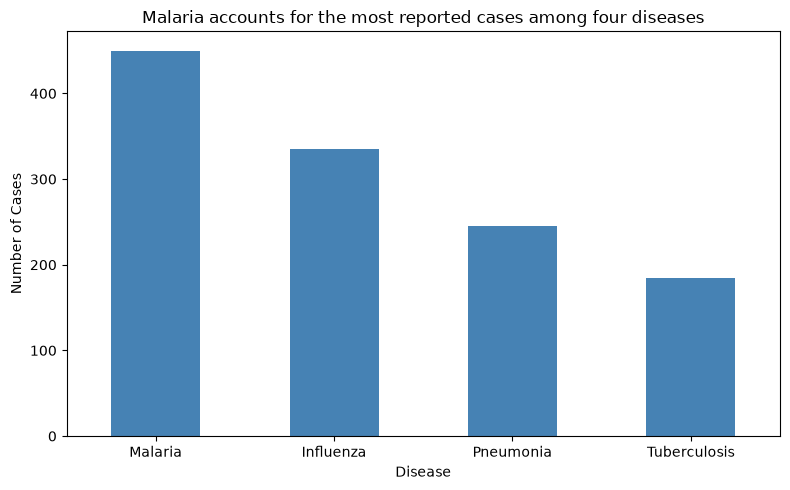

In [20]:
cases_by_disease = df.groupby("Disease")["Cases"].sum()

cases_by_disease

#Find the disease with the highest number of cases.

highest_disease = cases_by_disease.idxmax()
highest_cases = cases_by_disease.max()

print(
    f"{highest_disease} has the highest number of reported cases "
    f"with {highest_cases} cases."
)
#Create the Chart
plt.figure(figsize=(8, 5))

cases_by_disease.sort_values(ascending=False).plot(
    kind="bar",
    color="steelblue"
)

plt.title(f"{highest_disease} accounts for the most reported cases among four diseases")
plt.xlabel("Disease")
plt.ylabel("Number of Cases")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../reports/day01_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Result
Malaria had the highest number of reported cases in our  dataset.